# EDA — Bitext Retail eCommerce

Este notebook documenta o corpus usado para a classificação de intenções. Os rótulos `category` e `intent` foram publicados pela fonte e são preservados pelo pipeline; não há criação de rótulos por palavras-chave.

> O B2W-Reviews01 continua como fonte complementar de avaliações reais em PT-BR para EDA e análise de feedback. Ele não é a variável-alvo deste classificador.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATASET = ROOT / 'data/processed/bitext_retail_intents.parquet'
REPORT = ROOT / 'data/processed/bitext_retail_intents_report.json'
assert DATASET.exists(), 'Execute primeiro: python scripts/build_bitext_intent_dataset.py'
df = pd.read_parquet(DATASET)
df.head()

,record_id,source_dataset,text,category,intent,tags,response,split
0,003079ca817208fff14fc9b4cd0cfe21455211a32e8c1f...,bitext/Bitext-retail-ecommerce-llm-chatbot-tra...,i have to add fucking items to the basket wher...,CART,add_product,BCILMQW,"We're accountable for, and we apologize for an...",test
1,00336bef6d6c3d75a8fba661d11f5bbff664dc6021edb5...,bitext/Bitext-retail-ecommerce-llm-chatbot-tra...,id like to add items to the basket can i get s...,CART,add_product,BCILMPQ,"Sure, I can help you with that! Adding items t...",test
2,0040dff5e511daa7638becdd257237de8374ead4c61217...,bitext/Bitext-retail-ecommerce-llm-chatbot-tra...,i got to add a product to the basket i need as...,CART,add_product,BCQ,I'm here to assist you with adding a product t...,test
3,01065b64e353dc7f03d2d2563a3c83635803df0875194e...,bitext/Bitext-retail-ecommerce-llm-chatbot-tra...,wanna add a product to the cart how could i do it,CART,add_product,BCILPQ,I'm happy to help! I'm here to assist you with...,test
4,014f46e5f2279f316c7574a89ea3059f8dbc740e480caf...,bitext/Bitext-retail-ecommerce-llm-chatbot-tra...,i want assistance adding fucking products to t...,CART,add_product,BMQWZ,We recognize the inconvenience and apologize f...,test


## 1. Estrutura e qualidade

Verificamos dimensão, tipos, valores ausentes, duplicatas exatas e distribuição das partições.

In [2]:
print('Shape:', df.shape)
display(df.dtypes.to_frame('dtype'))
display(df.isna().sum().to_frame('ausentes'))
print('Duplicatas exatas:', df.duplicated().sum())
display(df['split'].value_counts().reindex(['train', 'validation', 'test']).to_frame('registros'))
print('Intenções:', df['intent'].nunique(), '| Categorias:', df['category'].nunique())

Shape: (44884, 8)


,dtype
record_id,object
source_dataset,object
text,object
category,object
intent,object
tags,object
response,object
split,string[python]


,ausentes
record_id,0
source_dataset,0
text,0
category,0
intent,0
tags,0
response,0
split,0


Duplicatas exatas: 0


,registros
split,
train,35906
validation,4489
test,4489


Intenções: 46 | Categorias: 13


## 2. Distribuição dos rótulos

O modelo usará `intent` como variável-alvo. `category` é mantida como uma visão semântica mais ampla para análise e roteamento.

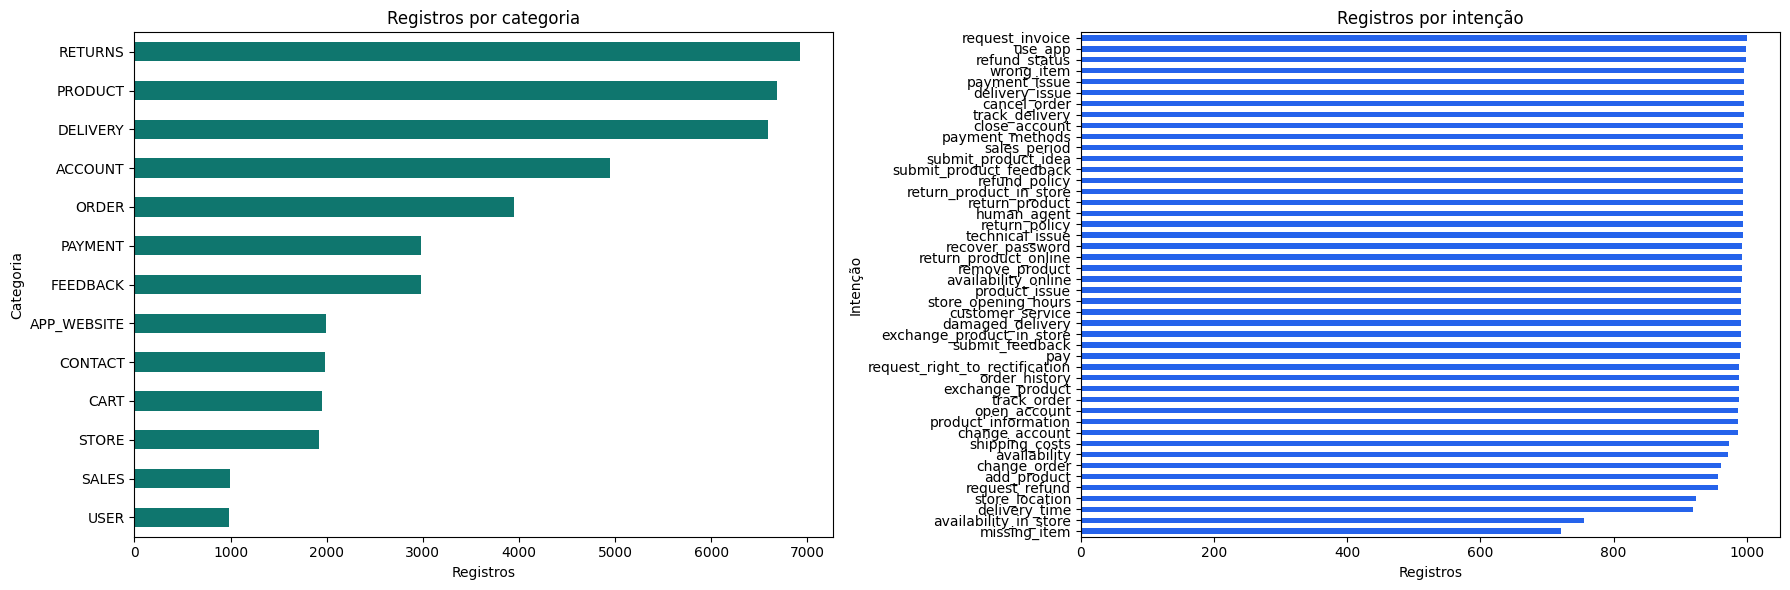

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
df['category'].value_counts().sort_values().plot.barh(ax=axes[0], color='#0f766e')
axes[0].set(title='Registros por categoria', xlabel='Registros', ylabel='Categoria')
df['intent'].value_counts().sort_values().plot.barh(ax=axes[1], color='#2563eb')
axes[1].set(title='Registros por intenção', xlabel='Registros', ylabel='Intenção')
plt.tight_layout()

## 3. Comprimento dos textos e divisão estratificada

A variação de tamanho informa a futura escolha de limite de tokens. A tabela também confirma que cada categoria foi distribuída entre treino, validação e teste.

,caracteres
count,44884.000000
mean,58.313252
std,15.070813
min,3.000000
50%,58.000000
95%,84.000000
max,131.000000


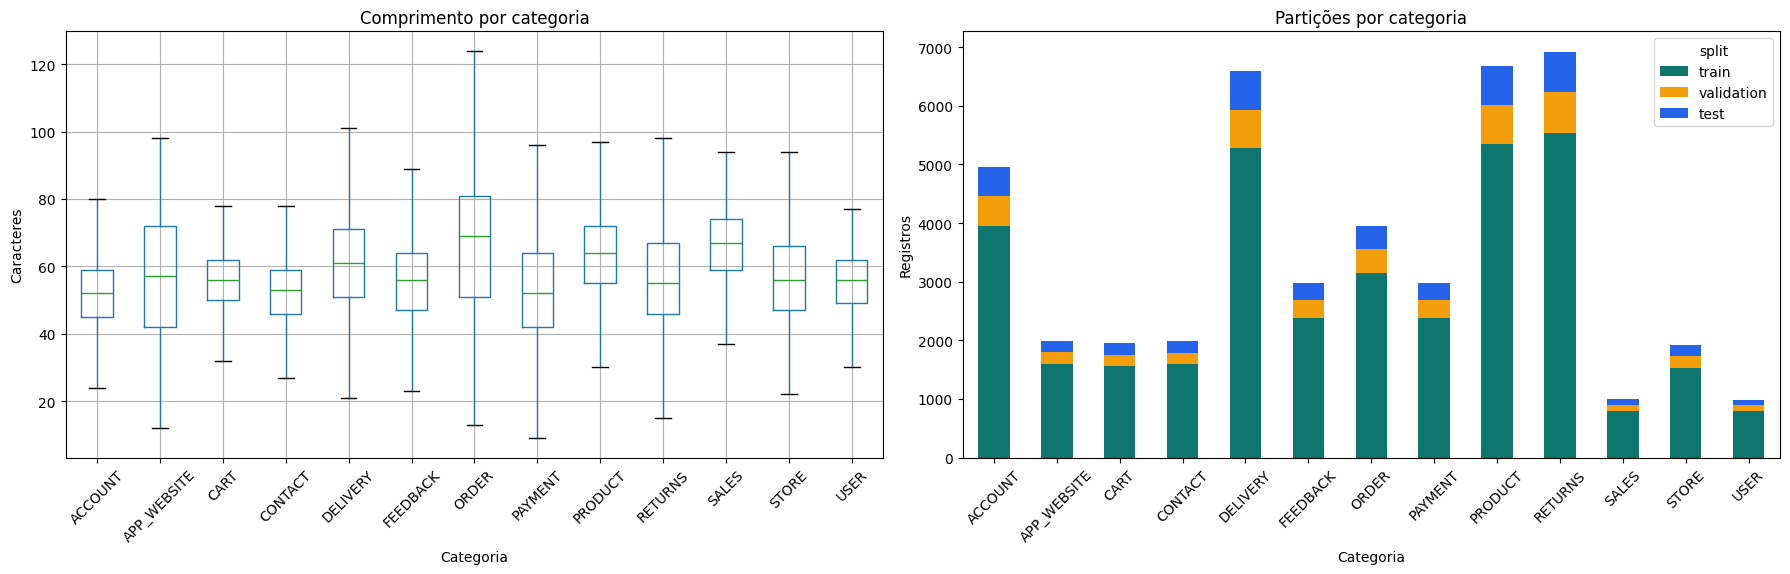

In [4]:
df = df.assign(text_length_chars=df['text'].str.len())
display(df['text_length_chars'].describe(percentiles=[.5, .95]).to_frame('caracteres'))
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
df.boxplot(column='text_length_chars', by='category', rot=45, ax=axes[0], showfliers=False)
axes[0].set(title='Comprimento por categoria', xlabel='Categoria', ylabel='Caracteres')
plt.suptitle('')
pd.crosstab(df['category'], df['split']).reindex(columns=['train', 'validation', 'test']).plot(
    kind='bar', stacked=True, ax=axes[1], color=['#0f766e', '#f59e0b', '#2563eb']
)
axes[1].set(title='Partições por categoria', xlabel='Categoria', ylabel='Registros')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()

## 4. Hipóteses

1. Entrega, produto e devoluções concentram uma parcela relevante das solicitações.
2. As intenções possuem volume suficiente e razoavelmente balanceado para uma primeira avaliação multiclasse.
3. Todas as intenções aparecem nas três partições.
4. O percentil 95 de comprimento deve orientar qualquer truncamento de texto no treinamento.

In [5]:
core = df[df['category'].isin(['DELIVERY', 'PRODUCT', 'RETURNS'])]
intent_counts = df['intent'].value_counts()
summary = {
    'participação DELIVERY + PRODUCT + RETURNS': f'{len(core) / len(df):.2%}',
    'menor classe': int(intent_counts.min()),
    'maior classe': int(intent_counts.max()),
    'razão maior/menor': round(intent_counts.max() / intent_counts.min(), 2),
    'intenções em todos os splits': bool((df.groupby('intent')['split'].nunique() == 3).all()),
    'P95 de caracteres': int(df['text_length_chars'].quantile(.95)),
}
pd.Series(summary, name='evidência')

participação DELIVERY + PRODUCT + RETURNS    45.00%
menor classe                                    721
maior classe                                   1000
razão maior/menor                              1.39
intenções em todos os splits                   True
P95 de caracteres                                84
Name: evidência, dtype: object

## Conclusão

O Bitext é o corpus rotulado de referência para a tarefa de intenção. O pipeline reprodutível está em `scripts/build_bitext_intent_dataset.py`, e o relatório detalhado está em `reports/bitext_retail_intents/relatorio.md`. A limitação metodológica — fonte híbrida/sintética em inglês — é registrada no README e no relatório.